# Análise de Comportamento no Spotify

## Objetivo
Este notebook realiza uma análise exploratória e modelagem para entender:
- Padrões de consumo musical
- Comportamento de skip
- Preferências por gênero
- Predição de skip a partir de features de uso


## Passo 0: Importação de bibliotecas e preparação do ambiente


In [131]:
import os
import json
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.cluster import KMeans


## Passo 1: Carregamento e consolidação dos dados

Nesta etapa os arquivos brutos são lidos e combinados em um único DataFrame.


In [ ]:
caminho_pasta = "../data/raw"

lista_dfs = []

for arquivo in os.listdir(caminho_pasta):
    if arquivo.endswith(".json"):
        caminho_completo = os.path.join(caminho_pasta, arquivo)
        
        with open(caminho_completo, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        df_temp = pd.DataFrame(data)
        lista_dfs.append(df_temp)

df_final = pd.concat(lista_dfs, ignore_index=True)

print(df_final.shape)

(113224, 26)


### Visualização inicial dos dados

Exibimos as primeiras linhas para validar a estrutura.


In [69]:
display(df_final.head())

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,user,artist_id,artist_genres
0,2024-11-21T16:08:39Z,android,211000,BR,2804:38a:a034:8d4c:0:60:111:9601,Papo Reto (Prazer É Sexo O Resto É Negócio),Charlie Brown Jr.,Bocas Ordinárias,spotify:track:0B5nSzWGWwvYbKl3GvCMuZ,None,...,trackdone,trackdone,False,False,False,1732205107,False,Cury,1on7ZQ2pvgeQF4vmIA09x5,"[brazilian rock, mpb, brazilian pop]"
1,2024-11-21T16:11:11Z,android,151666,BR,2804:38a:a034:8d4c:0:60:111:9601,Proibida Pra Mim (Grazon) - Ao Vivo,Charlie Brown Jr.,Acústico,spotify:track:2ScU6iEvgb0TIuKiyem9rg,None,...,trackdone,trackdone,False,False,False,1732205319,False,Cury,1on7ZQ2pvgeQF4vmIA09x5,"[brazilian rock, mpb, brazilian pop]"
2,2024-11-21T16:13:33Z,android,141133,BR,2804:38a:a034:8d4c:0:60:111:9601,O Côro Vai Comê,Charlie Brown Jr.,Transpiração Continua Prolongada,spotify:track:3RRroToeh491CkWyqGLCEt,None,...,trackdone,trackdone,False,False,False,1732205471,False,Cury,1on7ZQ2pvgeQF4vmIA09x5,"[brazilian rock, mpb, brazilian pop]"
3,2024-11-21T16:17:04Z,android,210666,BR,2804:38a:a034:8d4c:0:60:111:9601,Pontes Indestrutíveis,Charlie Brown Jr.,"Ritmo, Ritual E Responsa",spotify:track:74Es0YAvJFbFCZ6ULMcydb,None,...,trackdone,trackdone,False,False,False,1732205613,False,Cury,1on7ZQ2pvgeQF4vmIA09x5,"[brazilian rock, mpb, brazilian pop]"
4,2024-11-21T16:33:56Z,android,184093,BR,2804:38a:a034:8d4c:0:60:111:9601,Tudo Pro Alto - Ao Vivo,Charlie Brown Jr.,Acústico,spotify:track:6ZkeNE5zlcl13PbnzXdw38,None,...,trackdone,trackdone,False,False,False,1732205824,False,Cury,1on7ZQ2pvgeQF4vmIA09x5,"[brazilian rock, mpb, brazilian pop]"


### Preparação dos dados

In [70]:
df = df_final.copy()

# Converter timestamp
df["ts"] = pd.to_datetime(df["ts"])

# Explodir gêneros
df_genre = df.explode("artist_genres")

# Remover nulos
df_genre = df_genre[df_genre["artist_genres"].notna()]

# Converter ms para minutos
df_genre["minutes_played"] = df_genre["ms_played"] / 60000

## Passo 2: Funções auxiliares para visualização

Funções reutilizáveis para facilitar a análise gráfica das variáveis.


In [71]:
def gerar_grafico_colunas(df,titulo=' '):
    fig = px.bar(df,title=titulo)
    fig.show()

## Passo 3: Análise de consumo por gênero

Avaliação do tempo total e participação relativa de cada gênero.


In [72]:
genre_time = (
    df_genre
    .groupby("artist_genres")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
)

In [73]:
genre_share = genre_time / genre_time.sum()
gerar_grafico_colunas(genre_share.head(15),'Generos mais ouvidos por percentual de minutos')

### Skips behavior por genero

In [74]:
skip_rate = (
    df_genre
    .groupby("artist_genres")["skipped"]
    .mean()
)
gerar_grafico_colunas(skip_rate.drop_duplicates().sort_values(ascending=False).head(15),'Generos com maior quantidade de Skips')
gerar_grafico_colunas(skip_rate.drop_duplicates().sort_values(ascending=True).head(15),'Generos com menor quantidade de Skips')

In [75]:
avg_time_before_skip = (
    df_genre[df_genre["skipped"] == True]
    .groupby("artist_genres")["minutes_played"]
    .mean()
    .sort_values()
)
gerar_grafico_colunas(avg_time_before_skip.head(15),'Tempo médio antes de skipar por Gênero')


In [76]:
genre_analysis = pd.concat(
    [genre_share, skip_rate],
    axis=1
)

genre_analysis.columns = ["market_share", "skip_rate"]
genre_analysis["skip_adjusted_score"] = (
    genre_analysis["market_share"] * (1 - genre_analysis["skip_rate"])
)

genre_analysis.sort_values("skip_adjusted_score", ascending=False).head(15)

,market_share,skip_rate,skip_adjusted_score
artist_genres,,,
rock,0.119317,0.297124,0.083865
mpb,0.067186,0.342257,0.044191
alternative metal,0.058275,0.290865,0.041325
brazilian pop,0.060745,0.345316,0.039769
brazilian rock,0.060461,0.349916,0.039305
nu metal,0.053424,0.290073,0.037927
rap metal,0.052487,0.284573,0.037551
metal,0.055112,0.370150,0.034712
hard rock,0.046330,0.332328,0.030933


## Passo 4: Diversificação musical

Cálculo da entropia para medir o nível de diversidade nos gêneros ouvidos.


In [77]:
p = genre_share.values

entropy = -np.sum(p * np.log(p))
entropy

np.float64(3.533768798908844)

In [78]:
max_entropy = np.log(len(p))
normalized_entropy = entropy / max_entropy
normalized_entropy

np.float64(0.6372688402292422)

Entropia por tempo (quanto mais próximo de 1 vc concentra tempo em mais generos)

In [79]:
p_time = genre_time / genre_time.sum()

entropy_time = -np.sum(p_time * np.log(p_time))
entropy_time

np.float64(3.533768798908844)

In [80]:
print("Entropia por frequência:", entropy)
print("Entropia por tempo:", entropy_time)

Entropia por frequência: 3.533768798908844
Entropia por tempo: 3.533768798908844


## Passo 5: Evolução da diversidade ao longo do tempo


In [81]:
df_genre["year_month"] = df_genre["ts"].dt.to_period("M")

monthly_entropy = []

for period, group in df_genre.groupby("year_month"):
    p = (
        group["artist_genres"]
        .value_counts(normalize=True)
        .values
    )
    h = -np.sum(p * np.log(p))
    monthly_entropy.append((period, h))

monthly_entropy_df = pd.DataFrame(monthly_entropy, columns=["period", "entropy"])
monthly_entropy_df.set_index("period", inplace=True)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_4720\1711665611.py:1: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



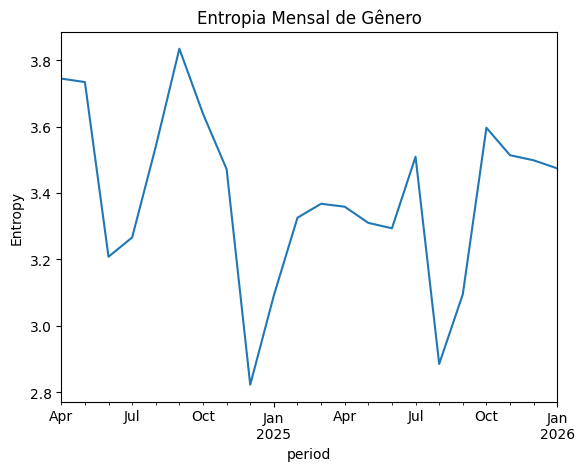

In [82]:
plt.figure()
monthly_entropy_df["entropy"].plot()
plt.title("Entropia Mensal de Gênero")
plt.ylabel("Entropy")
plt.show()

## Passo 6: Relação entre skip e características das músicas


In [83]:
df_genre["skip_numeric"] = df_genre["skipped"].astype(int)

correlation = df_genre[["minutes_played", "skip_numeric"]].corr()
correlation

,minutes_played,skip_numeric
minutes_played,1.000000,-0.741217
skip_numeric,-0.741217,1.000000


### Índice de tolerância por gênero

Compara o tempo médio das músicas ouvidas vs. puladas.


In [84]:
tolerance = (
    df_genre
    .groupby("artist_genres")
    .apply(lambda x: 
           x[x["skipped"] == False]["minutes_played"].mean() /
           x["minutes_played"].mean()
          )
)

tolerance.sort_values(ascending=False).head(15)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_4720\3784900526.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



artist_genres
christmas         5.125159
horror punk       4.866150
funk melody       4.410810
electro           3.809231
electronic        3.809231
brazilian bass    3.809231
punk              3.257284
classical         3.218596
britpop           2.985863
skate punk        2.942679
big room          2.935776
musicals          2.931549
hyperpop          2.733577
big band          2.688380
swing music       2.688380
dtype: float64

### Entropia condicional de skip

Mede a incerteza do comportamento de skip dentro de cada gênero.


In [85]:
def binary_entropy(p):
    if p in [0,1]:
        return 0
    return -p*np.log(p) - (1-p)*np.log(1-p)

skip_entropy_by_genre = skip_rate.apply(binary_entropy)
skip_entropy_by_genre.sort_values(ascending=False).head(15)

artist_genres
adult standards      0.693147
chanson              0.693147
electroclash         0.693147
electronica          0.693147
french pop           0.693147
frenchcore           0.693147
piseiro              0.693147
metalcore            0.693147
witch house          0.693147
pagode baiano        0.693147
variété française    0.693147
folk pop             0.692864
neo soul             0.692818
hardstyle            0.692688
stoner rock          0.692055
Name: skipped, dtype: float64

## Passo 7: Feature Engineering e preparação para modelagem


In [108]:
df = df_genre.copy()

df["skip_numeric"] = df["skipped"].astype(int)
df["minutes_played"] = df["ms_played"] / 60000
df["ts"] = pd.to_datetime(df["ts"])

df = df[df["artist_genres"].notna()]

In [109]:
df.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'user', 'artist_id',
       'artist_genres', 'minutes_played', 'year_month', 'skip_numeric'],
      dtype='object')

In [110]:
genre_time = df.groupby("artist_genres")["minutes_played"].sum()
genre_share = genre_time / genre_time.sum()

# Skip rate
skip_rate = df.groupby("artist_genres")["skip_numeric"].mean()

# Tempo médio
genre_avg_time = df.groupby("artist_genres")["minutes_played"].mean()

# Tolerância
tolerance = (
    df.groupby("artist_genres")
    .apply(lambda x:
           x[x["skip_numeric"] == 0]["minutes_played"].mean()
           / x["minutes_played"].mean()
           if x["minutes_played"].mean() > 0 else 0)
)

# Entropia binária do skip
def binary_entropy(p):
    if p in [0, 1]:
        return 0
    return -p*np.log(p) - (1-p)*np.log(1-p)

skip_entropy_by_genre = skip_rate.apply(binary_entropy)

# Construir dataframe consolidado
# ==========================================================
# MÉTRICAS POR GÊNERO (VERSÃO ROBUSTA)
# ==========================================================

genre_features = pd.DataFrame({
    "genre_skip_rate": skip_rate,
    "genre_skip_entropy": skip_entropy_by_genre,
    "genre_avg_time": genre_avg_time,
    "genre_tolerance": tolerance,
    "genre_market_share": genre_share
})

# 🔒 Não remover gêneros — preencher valores ausentes
genre_features = genre_features.fillna(0)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_4720\1354871974.py:13: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [111]:
genre_features.columns

Index(['genre_skip_rate', 'genre_skip_entropy', 'genre_avg_time',
       'genre_tolerance', 'genre_market_share'],
      dtype='object')

In [112]:
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(genre_features)

kmeans = KMeans(n_clusters=4, random_state=42)
genre_features["genre_cluster"] = kmeans.fit_predict(X_cluster)

In [113]:
# ======================================
# LIMPAR FEATURES ANTIGAS (se existirem)
# ======================================

cols_to_remove = [
    "genre_skip_rate",
    "genre_skip_entropy",
    "genre_avg_time",
    "genre_tolerance",
    "genre_market_share",
    "genre_cluster"
]

df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

In [114]:
df = df.merge(
    genre_features,
    left_on="artist_genres",
    right_index=True,
    how="left"
)

In [115]:
df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["year_month"] = df["ts"].dt.to_period("M")

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_4720\1844911186.py:4: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [116]:
monthly_entropy = []

for period, group in df.groupby("year_month"):
    p = group["artist_genres"].value_counts(normalize=True).values
    h = -np.sum(p * np.log(p)) if len(p) > 1 else 0
    monthly_entropy.append((period, h))

monthly_entropy_df = pd.DataFrame(monthly_entropy, columns=["year_month", "entropy"])
monthly_entropy_dict = monthly_entropy_df.set_index("year_month")["entropy"].to_dict()

df["monthly_entropy"] = df["year_month"].map(monthly_entropy_dict)

# Flag top gênero
top_genres = genre_share.sort_values(ascending=False).head(5).index
df["is_top_genre"] = df["artist_genres"].isin(top_genres).astype(int)

In [117]:
expected_features = [
    "genre_skip_rate",
    "genre_skip_entropy",
    "genre_avg_time",
    "genre_tolerance",
    "genre_market_share",
    "genre_cluster"
]

for col in expected_features:
    if col not in df.columns:
        print(f"Aviso: {col} não encontrado, criando como 0")
        df[col] = 0



features = [
    "minutes_played",
    "shuffle",
    "hour",
    "is_weekend",
    "monthly_entropy",
    "genre_skip_rate",
    "genre_skip_entropy",
    "genre_avg_time",
    "genre_tolerance",
    "genre_market_share",
    "is_top_genre",
    "genre_cluster"
]

X = df[features].dropna()
y = df.loc[X.index, "skip_numeric"]

In [ ]:
# Garantir que estamos usando o mesmo dataframe
df_model = df.copy()   # esse df já é o df_genre enriquecido

# Selecionar features
X = df_model[features]

# Selecionar target usando o MESMO índice
y = df_model["skip_numeric"]

# Remover NA mantendo alinhamento
mask = X.notna().all(axis=1)

X = X[mask]
y = y[mask]

## Passo 8: Separação de dados para treino e teste


In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
model=GradientBoostingClassifier()

## Passo 9: Treinamento do modelo de previsão de skip


In [128]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,      # L1
        reg_lambda=1.0,     # L2
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

In [ ]:
# param_grid = {
#     "feature_selection__k": [5, 8, "all"],
#     "pca__n_components": [None, 5, 8],
#     "model__n_estimators": [100, 200],
#     "model__learning_rate": [0.05, 0.1],
#     "model__max_depth": [3, 5]
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=cv,
#     scoring="roc_auc",
#     n_jobs=-1,
#     verbose=1
# )

In [129]:
pipeline.fit(X_train, y_train)

c:\Users\fernandopaiva-ieg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[07:39:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### Avaliação do modelo


In [130]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9279371774238304
ROC-AUC: 0.9596403245768242


In [ ]:
# best_model = grid.best_estimator_

# print("Melhores parâmetros:")
# print(grid.best_params_)

# print("\nMelhor AUC CV:")
# print(grid.best_score_)

# pred_proba = best_model.predict_proba(X_test)[:,1]
# pred_class = best_model.predict(X_test)

# print("\nAUC Teste:")
# print(roc_auc_score(y_test, pred_proba))

# print("\nClassification Report:")
# print(classification_report(y_test, pred_class))

In [ ]:
# pipeline_no_pca = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", GradientBoostingClassifier(
#         n_estimators=grid.best_params_["model__n_estimators"],
#         learning_rate=grid.best_params_["model__learning_rate"],
#         max_depth=grid.best_params_["model__max_depth"]
#     ))
# ])

# pipeline_no_pca.fit(X_train, y_train)

Feature importance